# Overview

To ensure that effort is strictly unimodal or multimodal according to the condition (gesture, vocal, multimodal), we will exclude trials that are above threshold

We will set this threshold based on data, rather than excluding anything a priori.

In [1]:
#| code-fold: true
#| code-summary: Code to prepare the environment

# Import packages
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

curfolder = os.getcwd()

# Here we store our merged final timeseries data
mergedfolder = os.path.join(curfolder, "..", "03_TS_processing", "TS_merged")
filestotrack = glob.glob(os.path.join(mergedfolder, "merged_*.csv"))
filestotrack = [x for x in filestotrack if "merged_0" not in x] # Get rid of those from dyad 0 (pilot data)
filestotrack = [x for x in filestotrack if os.path.basename(x).split("_")[2] != "1"] # Get rid of those that have in the basename third element 1 (part 1, different experiment)
print(f"Number of files in total: {len(filestotrack)}")

# Here we store the final data
cleaningfolder = os.path.join(curfolder, "Cleaning")

Number of files in total: 5238


## Data-driven threshold of modality use

In [2]:
#| code-fold: true
#| code-summary: Useful functions

def rms(x):
    """Calculate the root mean square of input array x.

    Args:
        x: Input array-like object

    Returns:
        float: RMS value of x, or np.nan if x is empty
    """
    x = np.asarray(x)
    return np.sqrt(np.mean(x ** 2))

def safe_percentile(x, q):
    """Calculate the q-th percentile of input array x, returning np.nan if x is empty.

    Args:
        x: Input array-like object
        q: Percentile to compute (0-100)

    Returns:
        float: q-th percentile of x, or np.nan if x is empty
    """
    x = np.asarray(x)
    return np.percentile(x, q) if len(x) else np.nan

def parse_condition_from_fileinfo(fileinfo):
    """
    Extract experimental condition from FileInfo string
    by substring matching (order-independent).

    Returns one of: 'gesture', 'vocal', 'multimodal', or 'unknown'
    """
    s = fileinfo.lower()

    gesture_tokens = {"gebaar", "gebaren", "gesture"}
    vocal_tokens = {"vocaal", "vocal", "geluiden"}
    multimodal_tokens = {"combinatie", "multimodal", "multi"}

    if any(tok in s for tok in gesture_tokens):
        return "gesture"
    elif any(tok in s for tok in vocal_tokens):
        return "vocal"
    elif any(tok in s for tok in multimodal_tokens):
        return "multimodal"
    else:
        print(f"Warning: could not parse condition from FileInfo: {fileinfo}")
        return "unknown"


def integral_abs(x):
    """Calculate the integral of absolute values of input array x.

    Args:
        x: Input array-like object

    Returns:
        float: Integral of absolute values of x, or np.nan if x is empty
    """
    x = np.asarray(x)
    return np.sum(np.abs(x)) if len(x) else np.nan


def extract_trial_features(
    csv_path,
    fileinfo_col="FileInfo",
    trialid_col="TrialID",
    signals=None
):
    """
    Extract trial-level features from a single CSV.

    signals: dict
        key   -> column name in CSV
        value -> short prefix used in feature names
    """

    if signals is None:
        signals = {
            "envelope_norm": "env",
            "RWrist_speed": "rwrist",
            "LWrist_speed": "lwrist",
            "arm_accKin_sum": "arm_acc",
            "arm_power": "arm_power",
            "f0": "f0",
        }

    usecols = list(signals.keys()) + [fileinfo_col, trialid_col]

    df = pd.read_csv(csv_path, usecols=usecols)

    trial_id = df[trialid_col].iloc[0]
    fileinfo = df[fileinfo_col].iloc[0]
    condition = parse_condition_from_fileinfo(fileinfo)

    features = {
        "trial_id": trial_id,
        "condition": condition,
    }

    for col, prefix in signals.items():
        x = df[col].dropna().values

        if len(x) == 0:
            features.update({
                f"{prefix}_mean": np.nan,
                f"{prefix}_rms": np.nan,
                f"{prefix}_p95": np.nan,
                f"{prefix}_integral": np.nan,
            })
            continue

        features.update({
            f"{prefix}_mean": float(np.mean(x)),
            f"{prefix}_rms": float(rms(x)),
            f"{prefix}_p95": float(np.percentile(x, 95)),
            f"{prefix}_integral": float(integral_abs(x)),
        })

    return features

In [3]:
if not os.path.exists(os.path.join(cleaningfolder, "condition_adherence_features.csv")):
    # prepare list to collect features
    all_features = []

    # loop over all files and collect features
    for file in filestotrack:
        print(f"Processing file: {file}")
        
        # collect features
        features = extract_trial_features(file)
        all_features.append(features)

        # save the df
        features_df = pd.DataFrame(all_features)
        features_df.to_csv(os.path.join(cleaningfolder, "condition_adherence_features.csv"), index=False)

else:
    # load the df
    features_df = pd.read_csv(os.path.join(cleaningfolder, "condition_adherence_features.csv"))



Condition: multimodal, 2nd percentile: 27.945007212046278, 75th percentile: 160.07968141024003
Condition: gesture, 2nd percentile: 21.791027619703215, 75th percentile: 111.20428000537186
Condition: vocal, 2nd percentile: 30.857606148413822, 75th percentile: 187.0264743039479


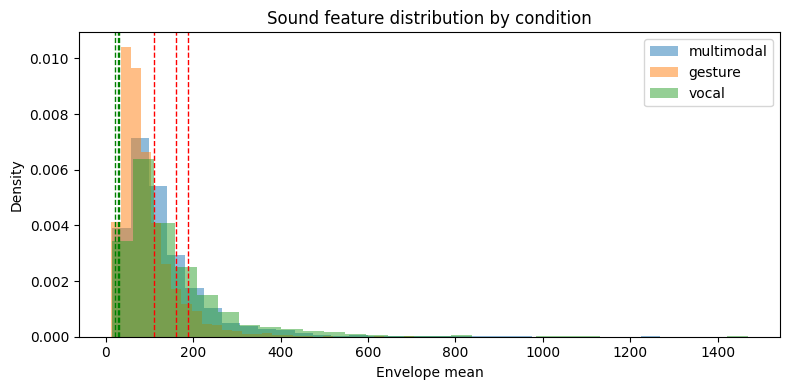

In [ ]:
plt.figure(figsize=(8, 4))

for cond in features_df["condition"].unique():
    subset = features_df[features_df["condition"] == cond]
    plt.hist(
        subset["env_integral"],
        bins=30,
        alpha=0.5,
        label=cond,
        density=True
    )

    # show the percentiles
    pct_2 = subset["env_integral"].quantile(0.02)
    pct_75 = subset["env_integral"].quantile(0.75)
    plt.axvline(pct_2, color='green', linestyle='dashed', linewidth=1)
    plt.axvline(pct_75, color='red', linestyle='dashed', linewidth=1)
    # print the value
    print(f"Condition: {cond}, 2nd percentile: {pct_2}, 75th percentile: {pct_75}")

plt.xlabel("Envelope mean")
plt.ylabel("Density")
plt.title("Sound feature distribution by condition")
plt.legend()
plt.tight_layout()
plt.show()


## Within participant percentile threshold

For each participant, we rank-normalize their vocal energy (env_rms) and arm movement (arm_acc_rms) into within-participant percentiles. Then we flag trials as violations — cases where the effort signal doesn't match what the condition demands:

- vocal trials: sound is nearly absent (<10th pct) or movement is surprisingly high (>80th pct)
- gesture trials: movement is nearly absent (<10th pct) or sound is surprisingly high (>80th pct)
- multimodal trials: either modality is nearly absent (<10th pct)

In [ ]:
# create colum participant_id where you take first and last elemets of trial_id
features_df["participant_id"] = features_df["trial_id"].apply(lambda x: x.split("_")[0] + "_" + x.split("_")[-1])

features_df["wrist_rms_mean"] = (
    features_df["rwrist_rms"] +
    features_df["lwrist_rms"]
) / 2

In [ ]:
SOUND_FEAT = "env_rms"
MOVE_FEAT  = "arm_acc_rms"

LOW  = 0.10   # essentially absent
HIGH = 0.80   # clearly present

features_df["sound_pct"] = np.nan
features_df["move_pct"] = np.nan

for pid in features_df["participant_id"].unique():
    mask = features_df["participant_id"] == pid

    features_df.loc[mask, "sound_pct"] = (
        features_df.loc[mask, SOUND_FEAT].rank(pct=True)
    )
    features_df.loc[mask, "move_pct"] = (
        features_df.loc[mask, MOVE_FEAT].rank(pct=True)
    )

mask = features_df["condition"] == "vocal"

features_df.loc[mask, "violation"] = (
    (features_df.loc[mask, "sound_pct"] < LOW) |
    (features_df.loc[mask, "move_pct"]  > HIGH)
)

mask = features_df["condition"] == "gesture"

features_df.loc[mask, "violation"] = (
    (features_df.loc[mask, "move_pct"]  < LOW) |
    (features_df.loc[mask, "sound_pct"] > HIGH)
)

mask = features_df["condition"] == "multimodal"

features_df.loc[mask, "violation"] = (
    (features_df.loc[mask, "sound_pct"] < LOW) |
    (features_df.loc[mask, "move_pct"]  < LOW)
)


In [ ]:
features_df.groupby("condition")["violation"].mean()

## Preparation of files for check

In [ ]:
# create fileid column, 
features_df["fileid"] = None

datatrials = glob.glob(os.path.join(curfolder, "..", "01_XDF_processing", "data", "Data_processed", "AudioVideo_final", "*.avi"))

for idx, row in features_df.iterrows():
    trialid = row["trial_id"]
    parts = trialid.split("_")
    if 'rein' in parts:
        filename = parts[0] + "_" + parts[1] + "_rein_trial_" + "_".join(parts[-2:-1]) + '_'
    else:
        filename = parts[0] + "_" + parts[1] + "_trial_" + "_".join(parts[2:-1]) + '_'

    print(f"Looking for files starting with: {filename}")
    matching_files = [f for f in datatrials if os.path.basename(f).startswith(filename)]

    if matching_files:
        #print(f"Found matching file: {matching_files[0]}")
        features_df.at[idx, "fileid"] = os.path.basename(matching_files[0])
    else:
        print(f"No matching file found for trialid: {trialid}")

# copy these files into curfolder + "/Violation_videos/"
import shutil

# create Violation_videos folder if it does not exist
violation_videos_folder = os.path.join(curfolder, "Violation_videos")
if not os.path.exists(violation_videos_folder):
    os.makedirs(violation_videos_folder)

for idx, row in features_df.iterrows():
    fileid = row["fileid"]
    if fileid is not None:
        source_path = os.path.join(curfolder, "..", "01_XDF_processing", "data", "Data_processed", "AudioVideo_final", fileid)
        dest_path = os.path.join(curfolder, "Violation_videos", fileid)
        shutil.copy(source_path, dest_path)
        print(f"Copied {fileid} to Violation_videos/")

All videos flagged as violations are now saved into Violation_videos, and are manually checked to ensure we exclude only true condition violations